# Experiment A Analysis: Mutation Testing Results

This notebook analyzes the results of Experiment A - testing 20 injected bugs (patches) against the hipBLASLt test suite.

## Questions to Answer
0. Do any patches need to be re-run because of non-standard GPU faults?
1. Which patches were caught by testing, and how many failures were found, in which test suite?
2. What is the minimum set of tests required to catch all detected mutations?


In [1]:
import json
import os
import re
from pathlib import Path
from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Configuration
EXPERIMENT_DIR = Path("experiment-a-results-2025-12-02-v1")
PATCHES_DIR = Path("patches")

# Load the experiment results summary
with open(EXPERIMENT_DIR / "experiment_a_results.json") as f:
    experiment_results = json.load(f)

print(f"Loaded results for {len(experiment_results)} patches")


Loaded results for 20 patches


In [4]:
def parse_log_file(log_path: Path) -> dict:
    """Parse a gtest log file to extract failure information."""
    result = {
        "total_tests": 0,
        "failed_tests": [],
        "test_suites": defaultdict(lambda: {"passed": 0, "failed": 0}),
        "gpu_errors": [],
        "crashed": False,
        "completed": False
    }
    
    if not log_path.exists():
        return result
    
    with open(log_path, 'r', errors='replace') as f:
        content = f.read()
    
    # Check for GPU errors (error code 700 = illegal memory access)
    gpu_error_pattern = r"(?:Hip error|Error code|hipError).*?(\d+)"
    gpu_errors = re.findall(gpu_error_pattern, content)
    result["gpu_errors"] = list(set(gpu_errors))
    
    # Check if test run completed normally (look for final summary line)
    if re.search(r"\[\s*PASSED\s*\]|\d+ tests from \d+ test suites ran", content):
        result["completed"] = True
    else:
        result["crashed"] = True
    
    # Extract total test count
    total_match = re.search(r"Running (\d+) tests? from", content)
    if total_match:
        result["total_tests"] = int(total_match.group(1))
    
    # Find all FAILED tests with their full names
    failed_pattern = r"\[  FAILED  \] ([^\s,]+)"
    failed_tests = re.findall(failed_pattern, content)
    result["failed_tests"] = failed_tests
    
    # Categorize by test suite
    for test in failed_tests:
        # Parse test suite from test name (e.g., "_/matmul_test.matmul/..." -> "_/matmul_test")
        if "." in test:
            suite = test.split(".")[0]
        else:
            suite = "Unknown"
        result["test_suites"][suite]["failed"] += 1
    
    # Count passed tests per suite from OK lines
    ok_pattern = r"\[       OK \] ([^\s]+)"
    ok_tests = re.findall(ok_pattern, content)
    for test in ok_tests:
        if "." in test:
            suite = test.split(".")[0]
        else:
            suite = "Unknown"
        result["test_suites"][suite]["passed"] += 1
    
    return result

# Parse all log files
parsed_results = {}
for patch_name, info in experiment_results.items():
    log_filename = os.path.basename(info["log_file"])
    log_path = EXPERIMENT_DIR / log_filename
    parsed_results[patch_name] = parse_log_file(log_path)
    parsed_results[patch_name]["experiment_failed"] = info["failed"]
    parsed_results[patch_name]["duration"] = info["duration"]

print("Parsed all log files successfully")


Parsed all log files successfully


## Question 0: GPU Faults Analysis

Check if any patches caused non-standard GPU faults that might require re-running.


In [7]:
# Analyze GPU faults and crash status
gpu_fault_analysis = []

for patch_name, results in parsed_results.items():
    patch_num = patch_name.split("_")[0]
    category = patch_name.split("_")[1]  # cat
    bug_type = patch_name.split("_")[2]  # a, b, c, d
    
    # Count tests actually executed (passed + failed from log)
    tests_executed = sum(s.get("passed", 0) + s.get("failed", 0) for s in results["test_suites"].values())
    
    gpu_fault_analysis.append({
        "patch": patch_name,
        "patch_num": patch_num,
        "category": bug_type,
        "tests_executed": tests_executed,
        "failed_count": len(results["failed_tests"]),
        "crashed": results["crashed"],
        "completed": results["completed"],
        "gpu_errors": ", ".join(results["gpu_errors"]) if results["gpu_errors"] else "None",
        "duration_sec": round(results["duration"], 1),
        "experiment_failed": results["experiment_failed"]
    })

df_faults = pd.DataFrame(gpu_fault_analysis)

# Display patches with GPU errors or crashes
print("=" * 80)
print("GPU FAULT ANALYSIS")
print("=" * 80)

crashed_or_errors = df_faults[(df_faults["crashed"] == True) | (df_faults["gpu_errors"] != "None")]
if len(crashed_or_errors) > 0:
    print("\n### Patches with GPU errors or crashes:")
    display(crashed_or_errors[["patch_num", "category", "tests_executed", "failed_count", "gpu_errors", "crashed", "duration_sec"]])
else:
    print("\nNo GPU errors or crashes detected.")

# Identify non-standard faults (not error 700 which is expected for memory violations)
print("\n### GPU Error Code Analysis:")
all_error_codes = set()
for errors in df_faults["gpu_errors"]:
    if errors != "None":
        for code in errors.split(", "):
            all_error_codes.add(code)

print(f"Unique GPU error codes encountered: {all_error_codes}")
print("\nError code 700 = 'illegal memory access' - This is EXPECTED for bugs causing memory violations")
print("Any other error codes would indicate potential hardware/driver issues requiring re-run")


GPU FAULT ANALYSIS

### Patches with GPU errors or crashes:


,patch_num,category,tests_executed,failed_count,gpu_errors,crashed,duration_sec
0,01,a,59,24,700,True,2.4
2,03,a,38800,3,700,True,371.7
8,09,b,3443,1124,700,True,45.4
12,13,c,38637,38630,700,True,1.9



### GPU Error Code Analysis:
Unique GPU error codes encountered: {'700'}

Error code 700 = 'illegal memory access' - This is EXPECTED for bugs causing memory violations
Any other error codes would indicate potential hardware/driver issues requiring re-run


In [8]:
# Determine if any patches need re-running
needs_rerun = []
for _, row in df_faults.iterrows():
    if row["gpu_errors"] != "None":
        # Check if only error 700 (expected) or other errors
        error_codes = [e.strip() for e in row["gpu_errors"].split(",")]
        unexpected_errors = [e for e in error_codes if e != "700"]
        if unexpected_errors:
            needs_rerun.append({
                "patch": row["patch"],
                "reason": f"Unexpected GPU error codes: {unexpected_errors}"
            })

if needs_rerun:
    print("⚠️  PATCHES REQUIRING RE-RUN:")
    for item in needs_rerun:
        print(f"  - {item['patch']}: {item['reason']}")
else:
    print("✅ NO PATCHES NEED RE-RUNNING")
    print("\nAll GPU errors encountered were error code 700 (illegal memory access),")
    print("which is the expected behavior when bugs cause memory violations.")
    print("These crashes are valid mutation detection results, not test infrastructure failures.")


✅ NO PATCHES NEED RE-RUNNING

All GPU errors encountered were error code 700 (illegal memory access),
which is the expected behavior when bugs cause memory violations.
These crashes are valid mutation detection results, not test infrastructure failures.


## Question 1: Mutation Detection Analysis

Which patches were caught by testing, how many failures were found, and in which test suites?


In [ ]:
# Build comprehensive detection summary
detection_data = []

for patch_name, results in parsed_results.items():
    patch_num = patch_name.split("_")[0]
    category = patch_name.split("_")[2]  # a, b, c, d
    description = "_".join(patch_name.split("_")[3:]).replace(".patch", "")
    
    # Determine detection status
    failed_count = len(results["failed_tests"])
    detected = failed_count > 0 or results["crashed"]
    
    # Count tests executed
    tests_executed = sum(s.get("passed", 0) + s.get("failed", 0) for s in results["test_suites"].values())
    
    # Get test suite breakdown
    suite_failures = dict(results["test_suites"])
    
    detection_data.append({
        "Patch #": patch_num,
        "Category": category.upper(),
        "Description": description,
        "Detected": "✅ YES" if detected else "❌ NO",
        "Tests Run": tests_executed,
        "Failed Tests": failed_count,
        "Crashed": "Yes" if results["crashed"] else "No",
        "Duration (s)": round(results["duration"], 1),
        "suite_data": suite_failures,
        "failed_tests_list": results["failed_tests"]
    })

df_detection = pd.DataFrame(detection_data)

# Summary statistics
total_patches = len(detection_data)
detected_patches = sum(1 for d in detection_data if "YES" in d["Detected"])
undetected_patches = total_patches - detected_patches

print("=" * 80)
print("MUTATION DETECTION SUMMARY")
print("=" * 80)
print(f"\nTotal patches tested: {total_patches}")
print(f"Mutations DETECTED:   {detected_patches} ({100*detected_patches/total_patches:.1f}%)")
print(f"Mutations ESCAPED:    {undetected_patches} ({100*undetected_patches/total_patches:.1f}%)")

# Display the main results table
print("\n### Detection Results by Patch:")
display(df_detection[["Patch #", "Category", "Description", "Detected", "Tests Run", "Failed Tests", "Crashed", "Duration (s)"]])

# Clarify detection modes
print("\n### Detection Modes:")
crashed_with_failures = sum(1 for d in detection_data if d["Crashed"] == "Yes" and d["Failed Tests"] > 0)
crashed_no_log_failures = sum(1 for d in detection_data if d["Crashed"] == "Yes" and d["Failed Tests"] == 0)
completed_with_failures = sum(1 for d in detection_data if d["Crashed"] == "No" and d["Failed Tests"] > 0)
completed_no_failures = sum(1 for d in detection_data if d["Crashed"] == "No" and d["Failed Tests"] == 0)

print(f"  - Crashed with logged failures:    {crashed_with_failures}")
print(f"  - Crashed before logging failures: {crashed_no_log_failures}") 
print(f"  - Completed with failures:         {completed_with_failures}")
print(f"  - Completed, all tests passed:     {completed_no_failures} (escaped mutations)")


MUTATION DETECTION SUMMARY

Total patches tested: 20
Mutations DETECTED:   4 (20.0%)
Mutations ESCAPED:    16 (80.0%)

### Detection Results by Patch:


,Patch #,Category,Description,Detected,Tests Run,Failed Tests,Crashed,Duration (s)
0,01,A,hipblaslt_swap_rows_cols,✅ YES,59,24,Yes,2.4
1,02,A,rocblaslt_mat_remove_type_check,❌ NO,40101,0,No,385.9
2,03,A,rocblaslt_transform_swap_lda_ldb,✅ YES,38800,3,Yes,371.7
3,04,A,hipblaslt_ext_stride_error,❌ NO,40101,0,No,381.5
4,05,A,utility_wrong_compute_string,❌ NO,40101,0,No,382.3
5,06,B,tensile_host_memset_off_by_one,❌ NO,40101,0,No,382.0
6,07,B,rocroller_gemm_trans_mixup,❌ NO,40101,0,No,380.6
7,08,B,handle_wavefront_size_error,❌ NO,40101,0,No,383.0
8,09,B,rocblaslt_auxiliary_attr_mixup,✅ YES,3443,1124,Yes,45.4
9,10,B,user_driven_tuning_parser_swap_mn,❌ NO,40101,0,No,381.0



### Detection Modes:
  - Crashed with logged failures:    4
  - Crashed before logging failures: 0
  - Completed with failures:         0
  - Completed, all tests passed:     16 (escaped mutations)



### Detection Rate by Bug Category:


,Total,Detected,Detection Rate
Category,,,
A,5,2,40.0%
B,5,1,20.0%
C,5,1,20.0%
D,5,0,0.0%


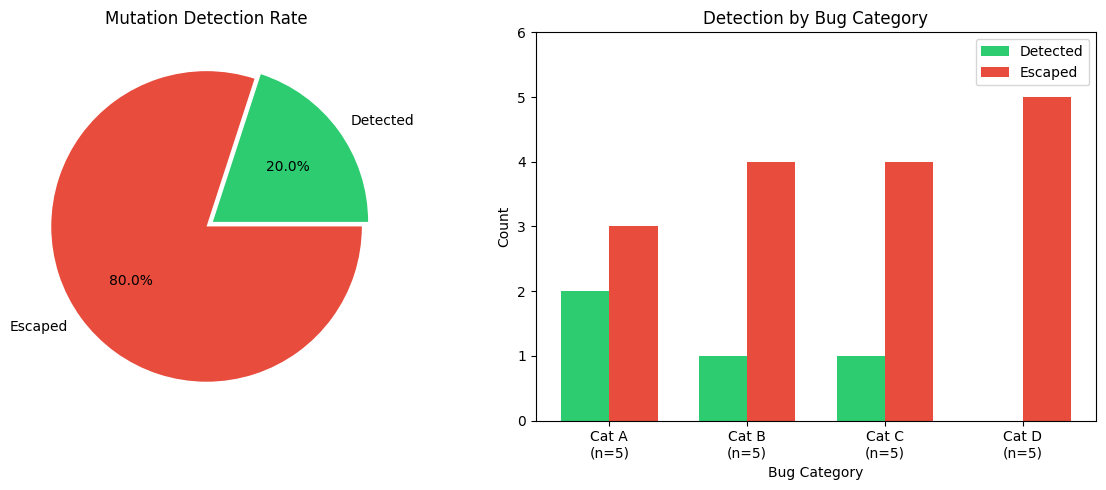

In [11]:
# Detection by category
print("\n### Detection Rate by Bug Category:")
category_stats = df_detection.groupby("Category").agg({
    "Patch #": "count",
    "Detected": lambda x: sum("YES" in v for v in x)
}).rename(columns={"Patch #": "Total", "Detected": "Detected"})
category_stats["Detection Rate"] = (category_stats["Detected"] / category_stats["Total"] * 100).round(1).astype(str) + "%"
display(category_stats)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart of detection status
detected_count = sum(1 for d in detection_data if "YES" in d["Detected"])
escaped_count = len(detection_data) - detected_count
axes[0].pie([detected_count, escaped_count], 
            labels=["Detected", "Escaped"], 
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            explode=(0.05, 0))
axes[0].set_title("Mutation Detection Rate")

# Bar chart by category
categories = ["A", "B", "C", "D"]
detected_by_cat = [sum(1 for d in detection_data if d["Category"] == cat and "YES" in d["Detected"]) for cat in categories]
total_by_cat = [sum(1 for d in detection_data if d["Category"] == cat) for cat in categories]
escaped_by_cat = [t - d for t, d in zip(total_by_cat, detected_by_cat)]

x = np.arange(len(categories))
width = 0.35

bars1 = axes[1].bar(x - width/2, detected_by_cat, width, label='Detected', color='#2ecc71')
bars2 = axes[1].bar(x + width/2, escaped_by_cat, width, label='Escaped', color='#e74c3c')

axes[1].set_xlabel('Bug Category')
axes[1].set_ylabel('Count')
axes[1].set_title('Detection by Bug Category')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"Cat {c}\n(n={t})" for c, t in zip(categories, total_by_cat)])
axes[1].legend()
axes[1].set_ylim(0, max(total_by_cat) + 1)

plt.tight_layout()
plt.show()


In [ ]:
# Detailed breakdown of failures by test suite for detected mutations
print("\n### Test Suite Breakdown for Detected Mutations:")
print("=" * 80)

for d in detection_data:
    if "YES" in d["Detected"] and d["Failed Tests"] > 0:
        print(f"\n📋 Patch {d['Patch #']} ({d['Description']}):")
        print(f"   Total failures: {d['Failed Tests']}")
        
        # Get suite breakdown
        suite_data = d["suite_data"]
        if suite_data:
            print("   By test suite:")
            for suite, counts in sorted(suite_data.items(), key=lambda x: x[1].get('failed', 0), reverse=True):
                failed = counts.get('failed', 0)
                if failed > 0:
                    print(f"      - {suite}: {failed} failures")


## Question 2: Minimum Test Set (Set Cover Problem)

Find the minimum set of tests required to detect all caught mutations.

This is a classic **Set Cover Problem**: Given a universe U (all detected mutations) and a collection S of subsets (tests that detect certain mutations), find the smallest subcollection that covers U.


In [ ]:
# Build the mutation-to-test mapping
# For each mutation (patch), which tests detected it?

# Universe: all detected mutations
detected_mutations = set()
for d in detection_data:
    if "YES" in d["Detected"]:
        detected_mutations.add(d["Patch #"])

print(f"Universe: {len(detected_mutations)} detected mutations: {sorted(detected_mutations)}")

# Build test -> mutations_detected mapping
test_to_mutations = defaultdict(set)

for d in detection_data:
    if "YES" in d["Detected"]:
        patch_id = d["Patch #"]
        failed_tests = d["failed_tests_list"]
        
        for test in failed_tests:
            test_to_mutations[test].add(patch_id)

print(f"\nTotal unique failing tests across all detected mutations: {len(test_to_mutations)}")


In [ ]:
def greedy_set_cover(universe: set, subsets: dict) -> list:
    """
    Greedy algorithm for the Set Cover problem.
    
    Args:
        universe: Set of all elements to cover
        subsets: Dict mapping subset_id -> set of elements it covers
    
    Returns:
        List of (subset_id, elements_covered) tuples representing the cover
    """
    uncovered = universe.copy()
    cover = []
    
    while uncovered:
        # Find the subset that covers the most uncovered elements
        best_subset = None
        best_coverage = set()
        
        for subset_id, elements in subsets.items():
            coverage = elements & uncovered
            if len(coverage) > len(best_coverage):
                best_subset = subset_id
                best_coverage = coverage
        
        if best_subset is None:
            break  # No more progress possible
            
        cover.append((best_subset, best_coverage))
        uncovered -= best_coverage
    
    return cover

# Run the greedy set cover algorithm
minimal_cover = greedy_set_cover(detected_mutations, test_to_mutations)

print("=" * 80)
print("MINIMUM TEST SET (Greedy Set Cover Solution)")
print("=" * 80)
print(f"\nMinimum number of tests needed: {len(minimal_cover)}")
print(f"These tests cover all {len(detected_mutations)} detected mutations\n")

print("### Minimal Test Set:")
for i, (test_name, mutations_covered) in enumerate(minimal_cover, 1):
    print(f"\n{i}. {test_name}")
    print(f"   Covers mutations: {sorted(mutations_covered)}")


In [ ]:
# Create a coverage matrix visualization
print("\n### Coverage Matrix (Test × Mutation):")

# Build the matrix
minimal_tests = [test for test, _ in minimal_cover]
mutation_list = sorted(detected_mutations)

coverage_matrix = []
for test in minimal_tests:
    row = [1 if m in test_to_mutations[test] else 0 for m in mutation_list]
    coverage_matrix.append(row)

# Create DataFrame for display
df_coverage = pd.DataFrame(
    coverage_matrix,
    index=[f"Test {i+1}" for i in range(len(minimal_tests))],
    columns=[f"Patch {m}" for m in mutation_list]
)

# Style the dataframe
def highlight_coverage(val):
    return 'background-color: #2ecc71; color: white' if val == 1 else ''

styled_df = df_coverage.style.applymap(highlight_coverage)
display(styled_df)

# Show full test names
print("\n### Test Name Legend:")
for i, test in enumerate(minimal_tests, 1):
    print(f"Test {i}: {test}")


In [ ]:
# Analyze test efficiency
print("\n### Test Suite Efficiency Analysis:")
print("=" * 80)

# Total tests in the suite
total_tests_in_suite = 40101  # From log files

# Tests that detected at least one mutation
detecting_tests = len(test_to_mutations)

# Minimal set size
minimal_set_size = len(minimal_cover)

print(f"\nTotal tests in suite:          {total_tests_in_suite:,}")
print(f"Tests detecting mutations:     {detecting_tests:,} ({100*detecting_tests/total_tests_in_suite:.2f}%)")
print(f"Minimal set for full coverage: {minimal_set_size}")
print(f"\nReduction factor: {total_tests_in_suite / minimal_set_size:.0f}x")
print(f"(Running {minimal_set_size} tests instead of {total_tests_in_suite:,} would still catch all detected mutations)")


## Summary


In [ ]:
# Final summary
print("=" * 80)
print("EXPERIMENT A - FINAL SUMMARY")
print("=" * 80)

print("\n📊 QUESTION 0: GPU Faults Requiring Re-run")
print("-" * 40)
if needs_rerun:
    print(f"⚠️  {len(needs_rerun)} patches need re-running due to unexpected GPU errors")
else:
    print("✅ No patches need re-running")
    print("   All GPU errors were expected (error 700 = illegal memory access)")

print("\n📊 QUESTION 1: Mutation Detection")
print("-" * 40)
print(f"   Total patches:     {total_patches}")
print(f"   Detected:          {detected_patches} ({100*detected_patches/total_patches:.1f}%)")
print(f"   Escaped:           {undetected_patches} ({100*undetected_patches/total_patches:.1f}%)")
print(f"\n   Detected patches:  {sorted([d['Patch #'] for d in detection_data if 'YES' in d['Detected']])}")
print(f"   Escaped patches:   {sorted([d['Patch #'] for d in detection_data if 'NO' in d['Detected']])}")

print("\n📊 QUESTION 2: Minimum Test Set")
print("-" * 40)
print(f"   Minimal tests needed: {len(minimal_cover)}")
print(f"   Suite reduction:      {total_tests_in_suite:,} → {len(minimal_cover)} tests")
print(f"   Efficiency gain:      {total_tests_in_suite / len(minimal_cover):.0f}x fewer tests")

print("\n" + "=" * 80)


In [ ]:
# Export the minimal test set to a file for future use
minimal_test_set_export = {
    "description": "Minimal test set for mutation coverage",
    "mutation_coverage": list(detected_mutations),
    "tests": [
        {
            "test_name": test,
            "covers_mutations": list(mutations)
        }
        for test, mutations in minimal_cover
    ],
    "statistics": {
        "total_mutations": total_patches,
        "detected_mutations": detected_patches,
        "escaped_mutations": undetected_patches,
        "total_tests_in_suite": total_tests_in_suite,
        "minimal_set_size": len(minimal_cover)
    }
}

with open("minimal_test_set.json", "w") as f:
    json.dump(minimal_test_set_export, f, indent=2)

print("✅ Minimal test set exported to 'minimal_test_set.json'")
